In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/fashion-retail-sales/Fashion_Retail_Sales.csv


# **Test**

In [30]:
df = pd.read_csv('/kaggle/input/fashion-retail-sales/Fashion_Retail_Sales.csv')
df['Review Rating'] = df['Review Rating'].fillna(0)  
print("First 5 records:", df.head())

First 5 records:    Customer Reference ID Item Purchased  Purchase Amount (USD) Date Purchase  \
0                   4018        Handbag                 4619.0    05-02-2023   
1                   4115          Tunic                 2456.0    11-07-2023   
2                   4019       Tank Top                 2102.0    23-03-2023   
3                   4097       Leggings                 3126.0    15-03-2023   
4                   3997         Wallet                 3003.0    27-11-2022   

   Review Rating Payment Method  
0            0.0    Credit Card  
1            2.0    Credit Card  
2            4.1           Cash  
3            3.2           Cash  
4            4.7           Cash  


# Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.dates as mdates
import warnings


from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
# Display basic information about the dataset
print(df.info())
print("\nSample data:")
print(df.head())

# Check missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3400 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB
None

Sample data:
   Customer Reference ID Item Purchased  Purchase Amount (USD) Date Purchase  \
0                   4018        Handbag                 4619.0    05-02-2023   
1                   4115          Tunic                 2456.0    11-07-2023   
2                   4019       Tank Top                 2102.0    23-03-2023   
3                   4097       Leggings                 3126.0    15-03-202

# Convert the date format to datetime format

In [33]:
# Convert 'Date Purchase' to datetime
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], format='%d-%m-%Y')
df['Purchase Month'] = df['Date Purchase'].dt.to_period('M') # Group by month

# Extract month and year for seasonal analysis
df['Month'] = df['Date Purchase'].dt.month
df['Year'] = df['Date Purchase'].dt.year
df['Season'] = pd.cut(df['Month'], 
                      bins=[0, 3, 6, 9, 12], 
                      labels=['Winter', 'Spring', 'Summer', 'Fall'],
                      include_lowest=True)
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].mean())

# Sales Analysis: Most Popular Fashion Items

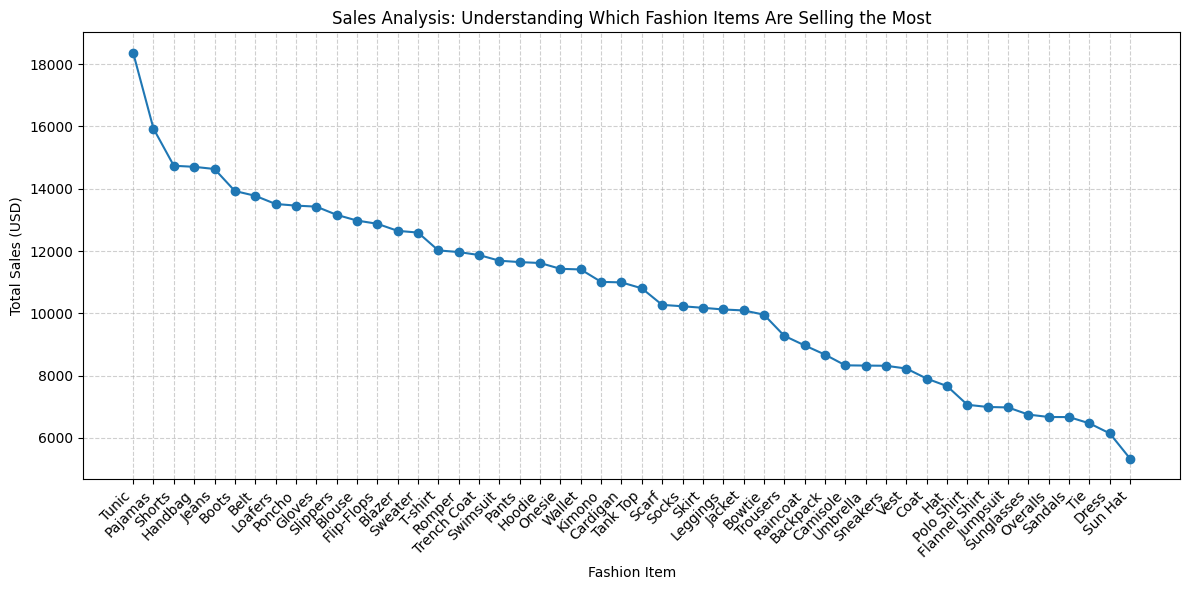

In [34]:
item_sales = df.groupby("Item Purchased")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(item_sales.index, item_sales.values, marker='o', linestyle='-')
plt.title("Sales Analysis: Understanding Which Fashion Items Are Selling the Most")
plt.xlabel("Fashion Item")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


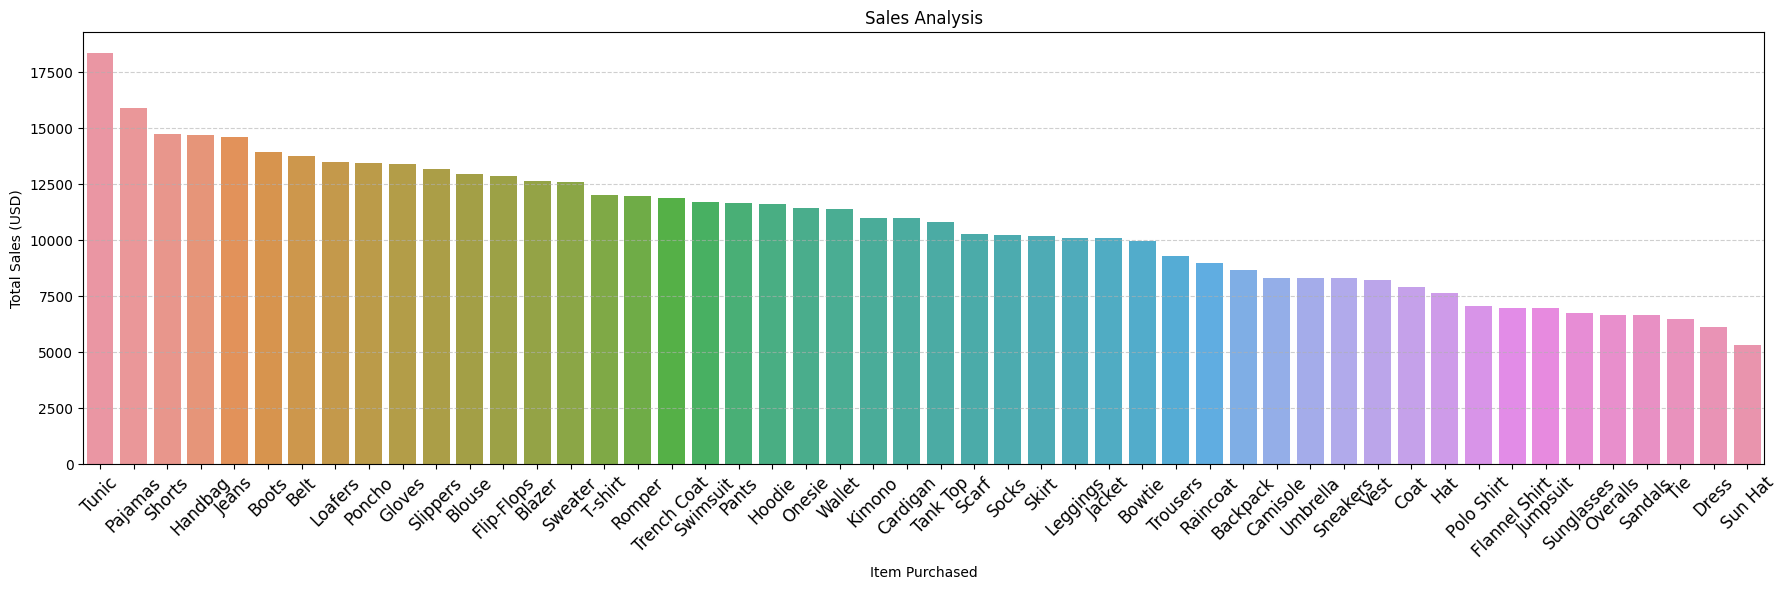

In [35]:
sales_by_item = df.groupby("Item Purchased")["Purchase Amount (USD)"].sum().sort_values(ascending=False).reset_index()
sales_by_item.columns = ['Item', 'Total Sales']

plt.figure(figsize=(18, 6))
sns.barplot(data=sales_by_item, x='Item', y='Total Sales')
plt.title("Sales Analysis")
plt.xlabel("Item Purchased")  
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Customer Insights: Purchase Behaviors and Spending Patterns
**Set style for visualizations**

In [36]:
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('/kaggle/input/fashion-retail-sales/Fashion_Retail_Sales.csv')
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


**Data preprocessing: Convert date column to datetime type and extract month**

In [37]:
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], format='%d-%m-%Y')
df['Purchase Month'] = df['Date Purchase'].dt.to_period('M') # Group by month

**Analysis 1: Average purchase amount by different payment methods**

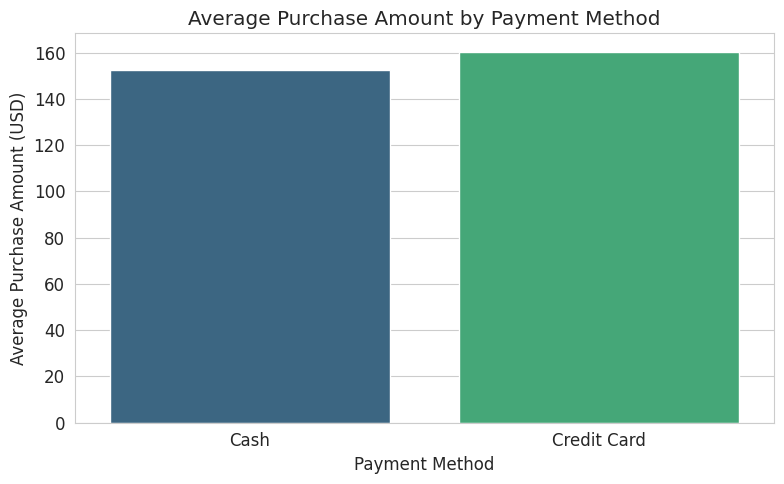

In [38]:
# Analysis Purpose: Compare the average spending levels for different payment methods (e.g., credit card, cash) to see if there are differences.
# Calculate the average purchase amount for different payment methods
avg_purchase_by_payment = df.groupby('Payment Method')['Purchase Amount (USD)'].mean().reset_index()

# Plot bar chart of average purchase amount by payment method
plt.figure(figsize=(8, 5))
sns.barplot(x='Payment Method', y='Purchase Amount (USD)', data=avg_purchase_by_payment, palette='viridis')
plt.title('Average Purchase Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Purchase Amount (USD)')
plt.tight_layout()
plt.show()

**Analysis 2: Top 10 most purchased items**

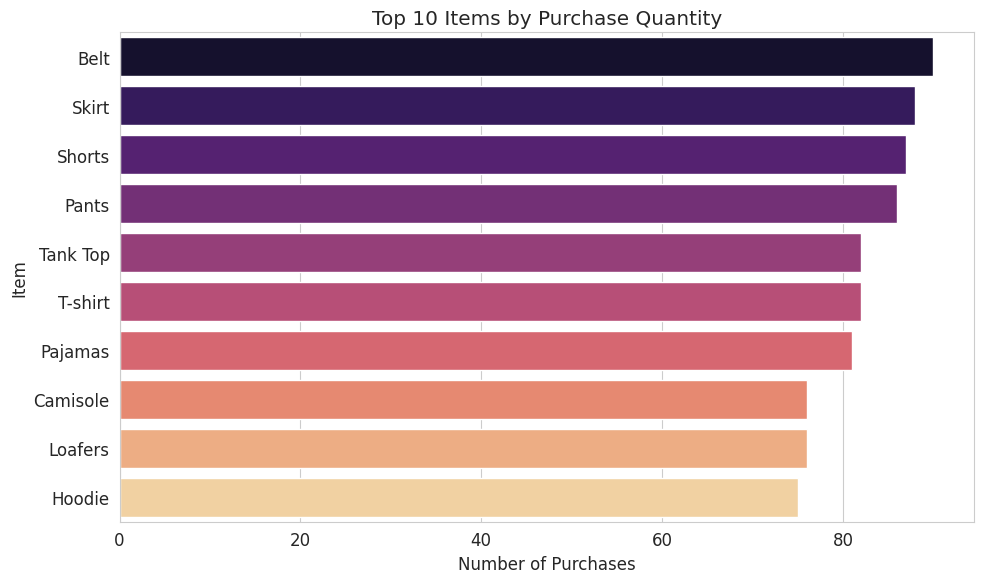

In [39]:
# Analysis Purpose: Identify the most popular items and understand which items perform best in terms of sales volume.
# Calculate the purchase count for each item and take the top 10
top_items_by_quantity = df['Item Purchased'].value_counts().head(10).reset_index()
top_items_by_quantity.columns = ['Item Purchased', 'Purchase Count']

# Plot bar chart of the top 10 most purchased items
plt.figure(figsize=(10, 6))
sns.barplot(x='Purchase Count', y='Item Purchased', data=top_items_by_quantity, palette='magma')
plt.title('Top 10 Items by Purchase Quantity')
plt.xlabel('Number of Purchases')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

**Analysis 3: Distribution of item review ratings and average ratings (Top 10)**

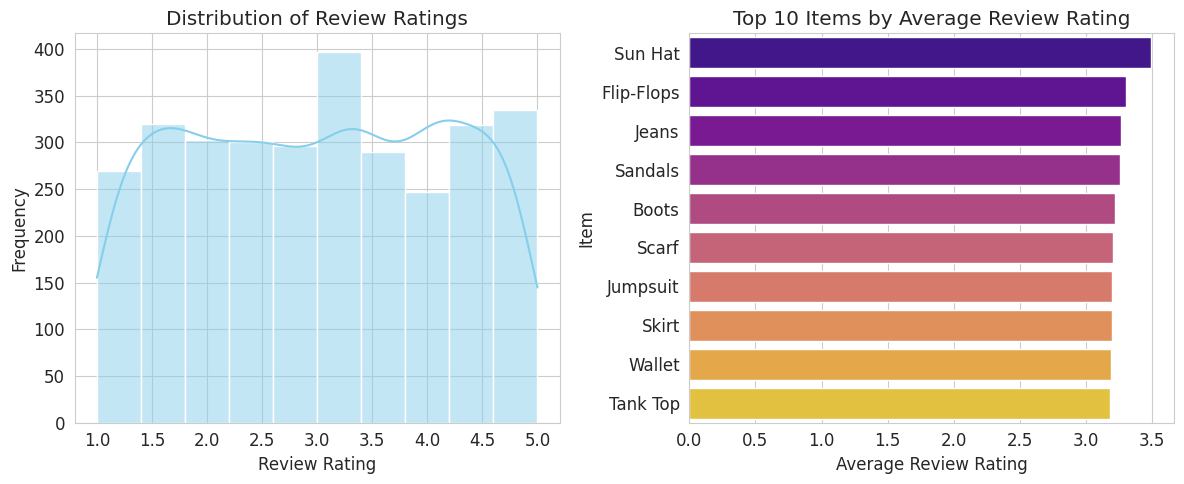

In [40]:
# Analysis Purpose: Understand the overall customer satisfaction distribution and identify the highest/lowest rated items, which is related to purchasing behavior and product quality.
# Analyze the distribution of review ratings
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # Create subplot
sns.histplot(df['Review Rating'].dropna(), bins=10, kde=True, color='skyblue')
plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Frequency')

# Calculate the average review rating for each item, and take the top 10
avg_rating_by_item = df.groupby('Item Purchased')['Review Rating'].mean().dropna().sort_values(ascending=False).head(10).reset_index()

# Plot bar chart of the top 10 items by average review rating
plt.subplot(1, 2, 2) # Create subplot
sns.barplot(x='Review Rating', y='Item Purchased', data=avg_rating_by_item, palette='plasma')
plt.title('Top 10 Items by Average Review Rating')
plt.xlabel('Average Review Rating')
plt.ylabel('Item')

plt.tight_layout() # Adjust layout to avoid overlap
plt.show()

# Trend Forecasting: Seasonal Trends in Fashion Retail

**Identifying Seasonal Trends**

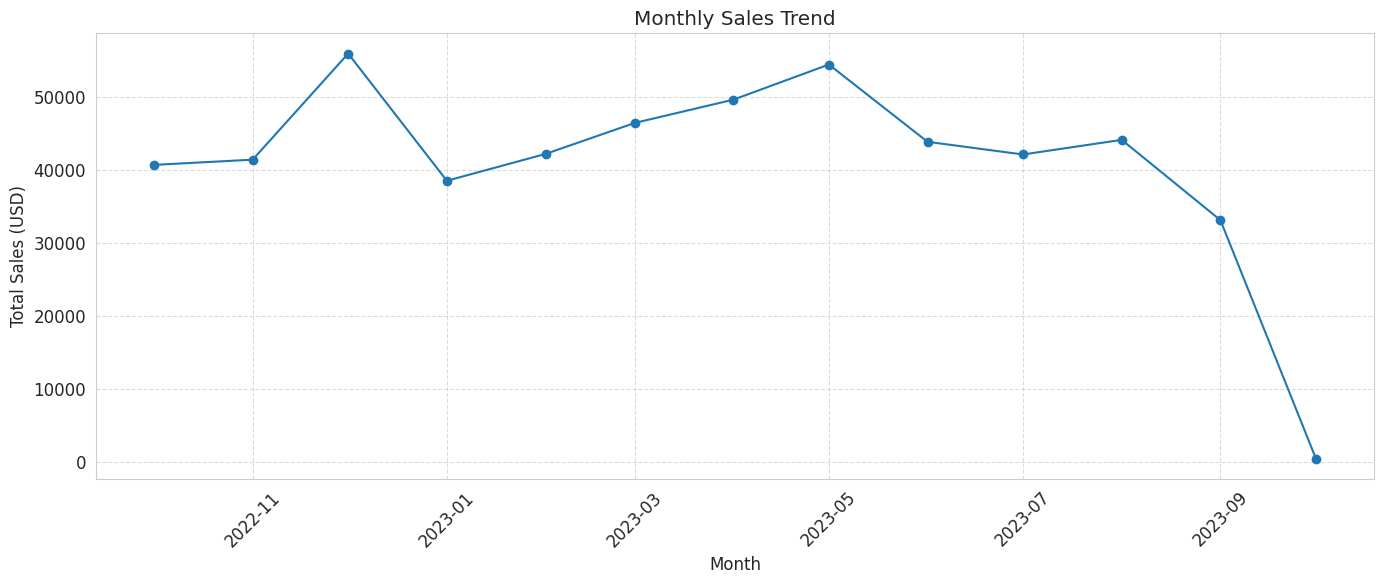

In [72]:
# Monthly sales trend
monthly_sales = df.groupby(df['Date Purchase'].dt.to_period('M'))['Purchase Amount (USD)'].sum().reset_index()
monthly_sales['Date Purchase'] = monthly_sales['Date Purchase'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date Purchase'], monthly_sales['Purchase Amount (USD)'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 - Look for consistent seasonal peaks (e.g., November) and troughs (e.g., February).
 - Compare yearly trends for growth or decline.
 - Possible causes: Holiday seasons, marketing campaigns.

***Seasonal Sales (Bar Chart)***

In [46]:
# Convert 'Date Purchase' to datetime
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], format='%d-%m-%Y')
df['Purchase Month'] = df['Date Purchase'].dt.to_period('M') # Group by month

# Extract month and year for seasonal analysis
df['Month'] = df['Date Purchase'].dt.month
df['Year'] = df['Date Purchase'].dt.year
df['Season'] = pd.cut(df['Month'], 
                      bins=[0, 3, 6, 9, 12], 
                      labels=['Winter', 'Spring', 'Summer', 'Fall'],
                      include_lowest=True)
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].mean())

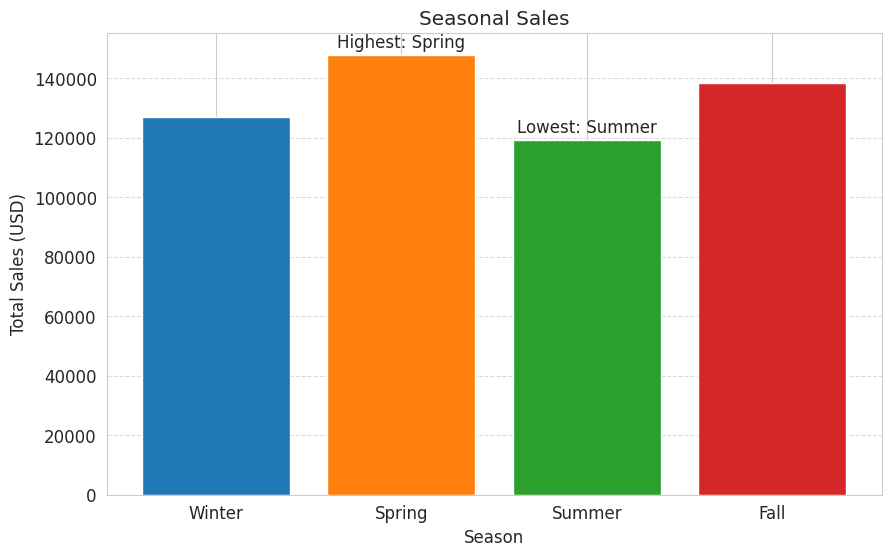

In [47]:
seasonal_sales = df.groupby(['Season'])['Purchase Amount (USD)'].sum().reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_sales['Season'], seasonal_sales['Purchase Amount (USD)'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Seasonal Sales')
plt.xlabel('Season')
plt.ylabel('Total Sales (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

highest = seasonal_sales.loc[seasonal_sales['Purchase Amount (USD)'].idxmax()]
lowest = seasonal_sales.loc[seasonal_sales['Purchase Amount (USD)'].idxmin()]
plt.annotate(f'Highest: {highest["Season"]}', 
             xy=(highest['Season'], highest['Purchase Amount (USD)']), 
             xytext=(0, 5), textcoords='offset points', ha='center')
plt.annotate(f'Lowest: {lowest["Season"]}', 
             xy=(lowest['Season'], lowest['Purchase Amount (USD)']), 
             xytext=(0, 5), textcoords='offset points', ha='center')

plt.show()

- Quantify sales differences between seasons.
- Most profitable season can guide inventory planning.
- Lowest season may need targeted marketing.

**Heatmap of Sales by Month and Year**

<function matplotlib.pyplot.show(close=None, block=None)>

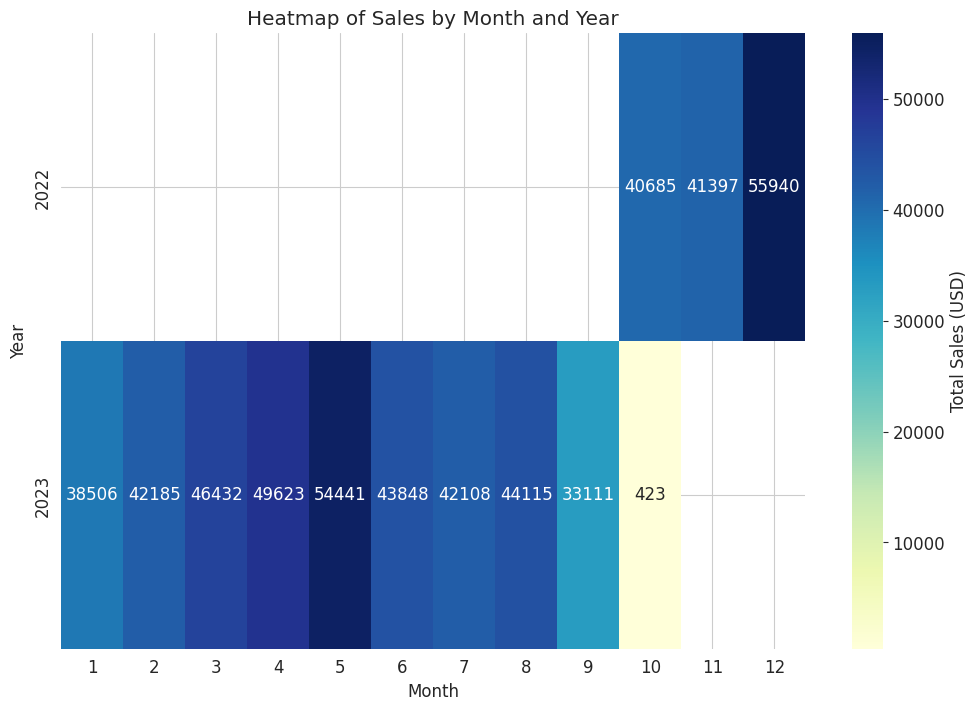

In [52]:
monthly_sales = df.groupby(['Year', 'Month'])['Purchase Amount (USD)'].sum().reset_index()
sales_pivot = monthly_sales.pivot(index='Year', columns='Month', values='Purchase Amount (USD)')
plt.figure(figsize=(12, 8))
sns.heatmap(sales_pivot, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label': 'Total Sales (USD)'})
plt.title('Heatmap of Sales by Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show

- Highlights monthly sales patterns across years.
- Identifies growth, decline, or unusual months visually.


# Payment Method Preferences

**Payment Method Distribution (Bar Chart)**

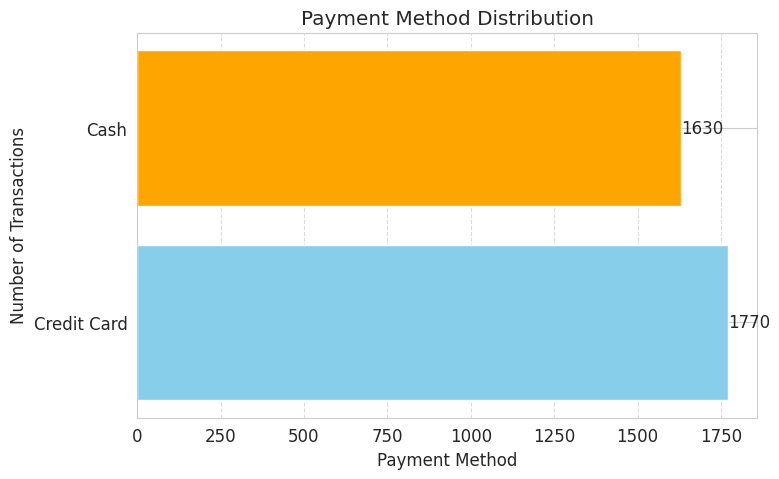

In [53]:
payment_counts = df['Payment Method'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.barh(payment_counts.index, payment_counts.values, color=['skyblue', 'orange'])
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    xval = bar.get_width()
    plt.text(
        xval + 0.5, 
        bar.get_y() + bar.get_height() / 2, 
        int(xval), 
        ha='left', 
        va='center' 
    )

plt.show()

**Average Purchase Amount by Payment Method**

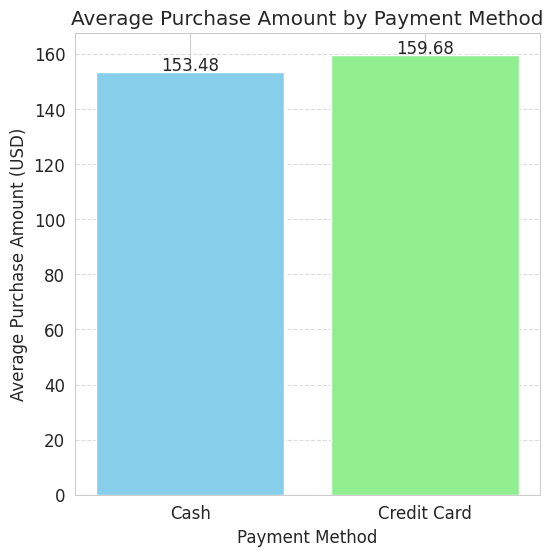

In [54]:
avg_purchase = df.groupby('Payment Method')['Purchase Amount (USD)'].mean()
plt.figure(figsize=(6, 6))
bars = plt.bar(avg_purchase.index, avg_purchase.values, color=['skyblue', 'lightgreen'])
plt.title('Average Purchase Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Purchase Amount (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha='center')
plt.show()

- Highlights payment methods linked to higher spending.
- Indicates revenue impact of payment preferences.

**Payment Method Trends Over Time (Line Plot)**

Date of annotation 2023-07-01 00:00:00 not in the data.


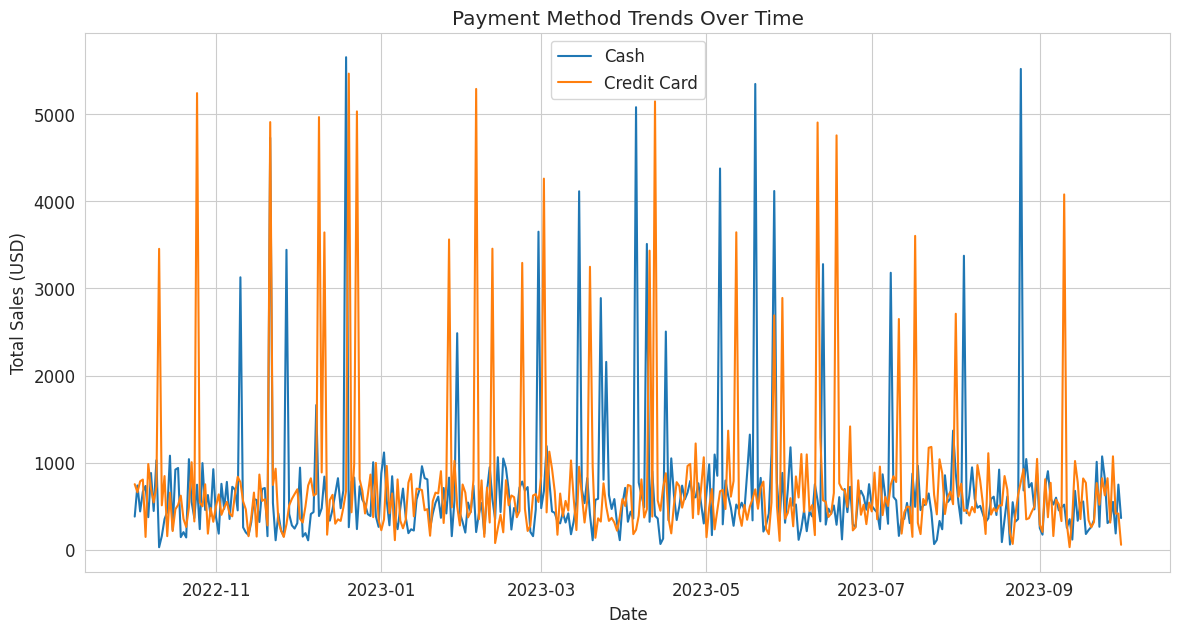

In [55]:
payment_trends = df.groupby(['Date Purchase', 'Payment Method'])['Purchase Amount (USD)'].sum().reset_index()
# Explicitly convert the date column format
payment_trends['Date Purchase'] = pd.to_datetime(payment_trends['Date Purchase'])

plt.figure(figsize=(14, 7))
for method in payment_trends['Payment Method'].unique():
    method_data = payment_trends[payment_trends['Payment Method'] == method]
    plt.plot(method_data['Date Purchase'], method_data['Purchase Amount (USD)'], label=method)

plt.title('Payment Method Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (USD)')
plt.legend()
plt.grid(True)

try:
    # Obtain an actual existing date from the data
    sample_date = payment_trends['Date Purchase'].dt.strftime('%Y-%m-%d').unique()[0]
    # Explicitly convert the annotation date
    annotation_date = pd.to_datetime('2023-07-01')
    if annotation_date in payment_trends['Date Purchase'].dt.date.unique():
        plt.annotate(
            'Shift to Credit Card',
            xy=(annotation_date, 5000), 
            xytext=(10, 10),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->')
        )
    else:
        print(f"Date of annotation {annotation_date} not in the data.")
except Exception as e:
    print(f"Failed to add annotation: {e}")

plt.show()

- Tracks evolving popularity of payment methods.
- Identifies trends or shifts (e.g., Credit Card surpassing Cash).
- Possible causes: New payment options, customer preferences.

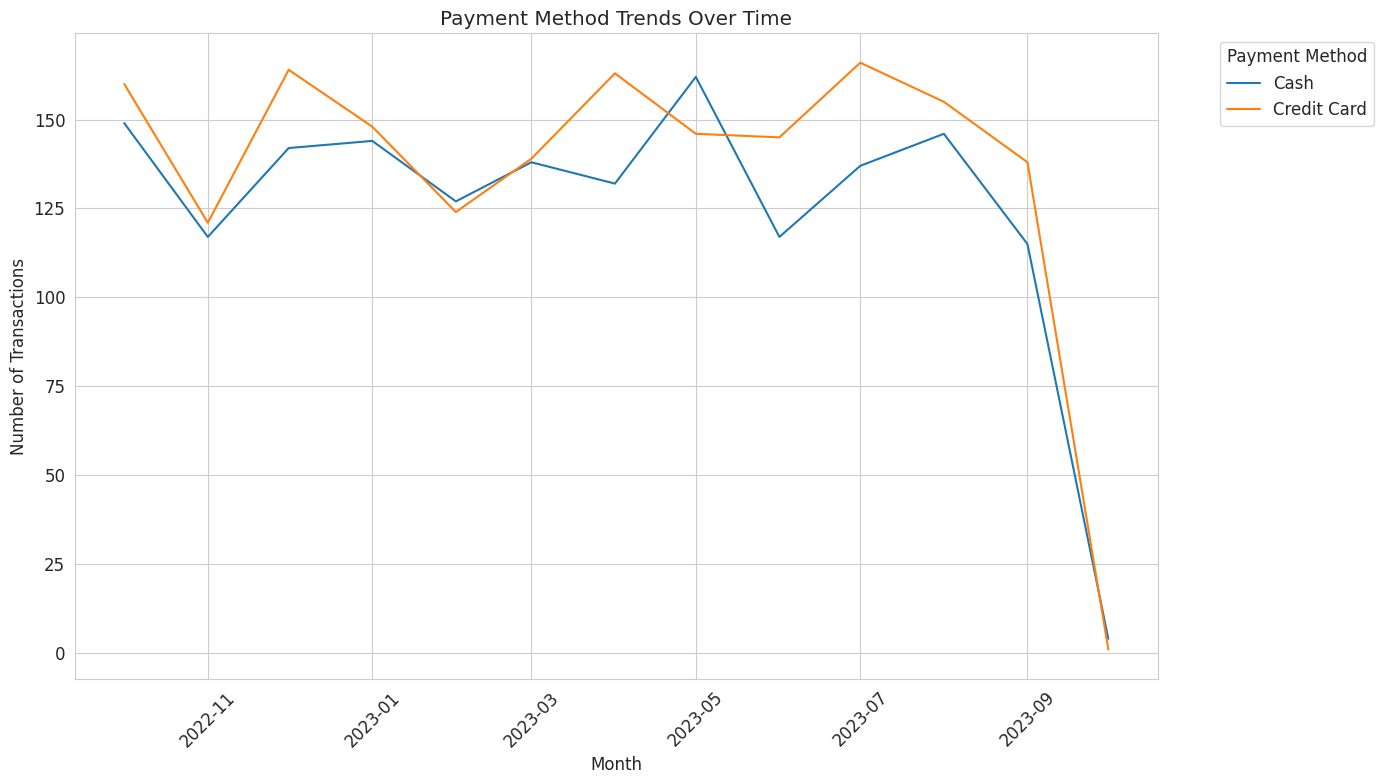

In [56]:
# ignore FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

# Payment method trends over time
payment_trend = df.groupby([df['Date Purchase'].dt.to_period('M'), 'Payment Method']).size().reset_index(name='Count')
payment_trend['Date Purchase'] = payment_trend['Date Purchase'].dt.to_timestamp()

plt.figure(figsize=(14, 8))
sns.lineplot(x='Date Purchase', y='Count', hue='Payment Method', data=payment_trend)
plt.title('Payment Method Trends Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Data preprocessing and random forest model training

In [67]:
# Load the dataset
# 1. Time-Based Features
# Convert the 'Date Purchase' to datetime format for time analysis
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], format='%d-%m-%Y')
df['Month'] = df['Date Purchase'].dt.month
df['Day_of_Week'] = df['Date Purchase'].dt.dayofweek

# 2. Customer History Features
df = df.sort_values('Date Purchase') #Sort by 'Date Purchase'
df['Num_Prev_Purchases'] = df.groupby('Customer Reference ID').cumcount()
df['Avg_Prev_Amount'] = df.groupby('Customer Reference ID')['Purchase Amount (USD)'].cumsum() / (df['Num_Prev_Purchases'] + 1)

# 3. Item Categorization
# To group similar products
item_categories = {
    'Clothing': ['Tunic', 'Tank Top', 'Leggings', 'Onesie', 'Jacket', 'Trousers', 'Jeans', 'Pajamas', 'Trench Coat', 'Poncho', 'Romper', 'T-shirt', 'Blazer', 'Boots', 'Sweater', 'Blouse', 'Swimsuit', 'Kimono', 'Cardigan', 'Pants', 'Hoodie', 'Dress', 'Flannel Shirt', 'Shorts', 'Polo Shirt', 'Coat', 'Overalls', 'Jumpsuit', 'Skirt', 'Raincoat', 'Vest'],
    'Accessories': ['Handbag', 'Wallet', 'Bowtie', 'Gloves', 'Belt', 'Scarf', 'Backpack', 'Tie', 'Hat', 'Sun Hat', 'Sunglasses', 'Umbrella'],
    'Footwear': ['Loafers', 'Slippers', 'Flip-Flops', 'Sneakers', 'Sandals']
}
def categorize_item(item):
    for category, items in item_categories.items():
        if item in items:
            return category
    return 'Other'
df['Item_Category'] = df['Item Purchased'].apply(categorize_item)

# Handle missing values
# mean --> missing 'Review Rating' & missing 'Purchase Amount (USD)'   
# 0 --> missing 'Avg_Prev_Amount'
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df['Purchase Amount (USD)'].mean())
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())
df['Avg_Prev_Amount'] = df['Avg_Prev_Amount'].fillna(0)

# Encode categorical variables
# Initialize LabelEncoder and transform 'Payment Method','Item_Category' to numerical values
le_payment = LabelEncoder()
df['Payment Method'] = le_payment.fit_transform(df['Payment Method'])
le_item_category = LabelEncoder()
df['Item_Category'] = le_item_category.fit_transform(df['Item_Category'])

# Features and target
features = ['Purchase Amount (USD)', 'Review Rating', 'Month', 'Day_of_Week', 'Num_Prev_Purchases', 'Avg_Prev_Amount', 'Item_Category']
X = df[features]
y = df['Payment Method'] #Target variable

# Time-based train-test split (e.g., 80% train, 20% test)
train_size = int(0.8 * len(df))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)# Fit the model on the training data


# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.5353
Precision: 0.5307
Recall: 0.5353
F1 Score: 0.5291


# Model Comparison and Visualization

                Model  Accuracy  Precision  Recall  F1 Score
8             MyModel    0.5353     0.5307  0.5353    0.5291
5          KNeighbors    0.5206     0.5198  0.5206    0.5198
6                 SVC    0.5147     0.4596  0.5147    0.3559
3    GradientBoosting    0.5059     0.5040  0.5059    0.5032
2        RandomForest    0.5044     0.5028  0.5044    0.5023
0  LogisticRegression    0.5015     0.4601  0.5015    0.3927
1        DecisionTree    0.4941     0.4943  0.4941    0.4942
7             XGBoost    0.4750     0.4737  0.4750    0.4738
4            AdaBoost    0.4735     0.4684  0.4735    0.4657


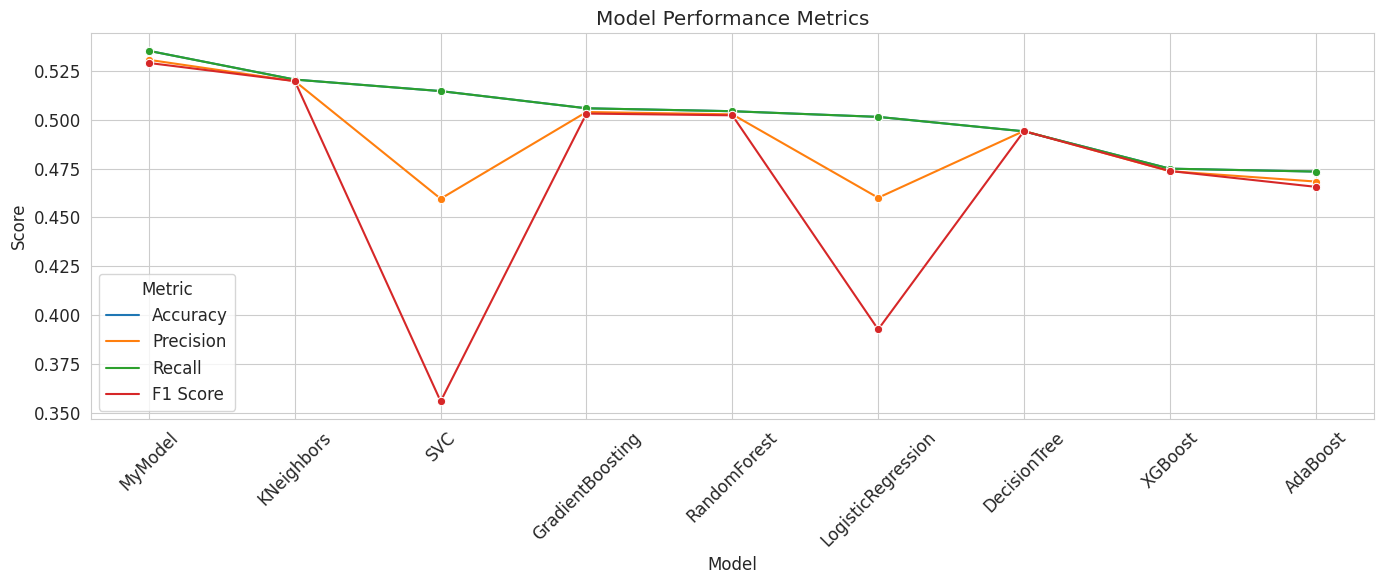

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNeighbors": KNeighborsClassifier(),
    "SVC": SVC(),
    "XGBoost": XGBClassifier(verbosity=0, use_label_encoder=False),
    "MyModel": None  
}

results = []
for name, model in models.items():
    if name == "MyModel":
        # Manually add the model results
        accuracy = 0.5353
        precision = 0.5307
        recall = 0.5353
        f1 = 0.5291
        results.append({
            'Model': name,
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1 Score': round(f1, 4)
        })
        continue
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df)

metrics_df = results_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'], var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.lineplot(data=metrics_df, x='Model', y='Score', hue='Metric', marker='o')
plt.title("Model Performance Metrics")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()